In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import (
    BertTokenizer, BertForSequenceClassification,
    TrainingArguments, Trainer,
)
from sklearn.metrics import accuracy_score, f1_score

print("GPU available:", torch.cuda.is_available())

GPU available: True


In [5]:
from transformers import Trainer
model_name = "bert-base-uncased"
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name, num_labels=2)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [6]:
dataset = load_dataset("sst2")
print("Train size      :", len(dataset["train"]))
print("Validation size :", len(dataset["validation"]))

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

Train size      : 67349
Validation size : 872


In [7]:
def tokenize(batch):
    return tokenizer(
        batch["sentence"],
        padding="max_length",
        truncation=True,
        max_length=128,
    )

tokenized_dataset = dataset.map(tokenize, batched=True)
tokenized_dataset.set_format(
    "torch", columns=["input_ids", "attention_mask", "label"]
)

Map:   0%|          | 0/67349 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Map:   0%|          | 0/1821 [00:00<?, ? examples/s]

In [8]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="weighted"),
    }

In [9]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",        
    save_strategy="epoch",
    logging_dir="./logs",
    logging_steps=100,
    load_best_model_at_end=True,
    learning_rate=2e-5,          
    warmup_steps=500,             
    weight_decay=0.01,           
    fp16=torch.cuda.is_available(),
    report_to="none",             
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [10]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics,
)
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.172076,0.242885,0.928899,0.928902
2,0.111768,0.278838,0.927752,0.927699
3,0.087596,0.338276,0.926606,0.926565


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=12630, training_loss=0.14810043402541184, metrics={'train_runtime': 1608.4086, 'train_samples_per_second': 125.619, 'train_steps_per_second': 7.852, 'total_flos': 1.329019985058048e+16, 'train_loss': 0.14810043402541184, 'epoch': 3.0})

In [11]:
print("--- Evaluation Results ---")
results = trainer.evaluate()
print(results)

--- Evaluation Results ---


{'eval_loss': 0.24361293017864227, 'eval_accuracy': 0.9288990825688074, 'eval_f1': 0.9289017014284685, 'eval_runtime': 1.563, 'eval_samples_per_second': 557.895, 'eval_steps_per_second': 17.914, 'epoch': 3.0}


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics,
)
trainer.train()

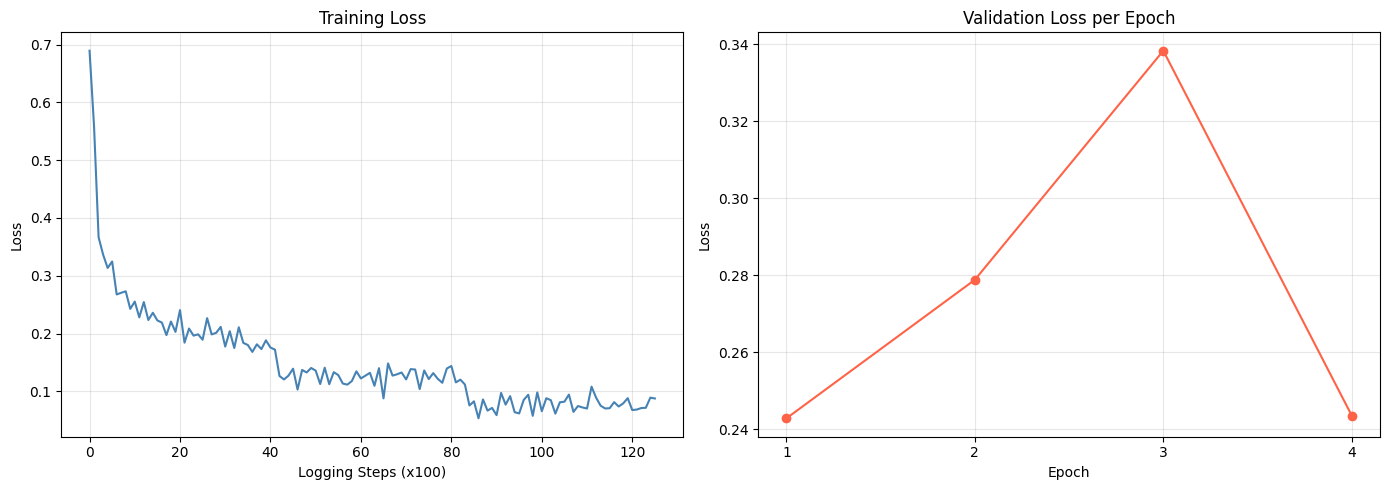

In [12]:
history = trainer.state.log_history

train_loss = [x["loss"] for x in history if "loss" in x and "eval_loss" not in x]
eval_loss  = [x["eval_loss"] for x in history if "eval_loss" in x]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_loss, color="steelblue")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Logging Steps (x100)")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, len(eval_loss)+1), eval_loss, marker="o", color="tomato")
axes[1].set_title("Validation Loss per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_xticks(range(1, len(eval_loss)+1))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("loss_curves.png", dpi=150)
plt.show()

In [13]:
LABEL = {0: "Negative", 1: "Positive"}

val_subset  = tokenized_dataset["validation"].select(range(5))
predictions = trainer.predict(val_subset)
preds       = np.argmax(predictions.predictions, axis=-1)

print("--- Example Predictions ---\n")
for i in range(5):
    sentence   = dataset["validation"][i]["sentence"]
    true_label = dataset["validation"][i]["label"]
    pred_label = int(preds[i]) 
    match      = "✓" if pred_label == true_label else "✗"

    print(f"[{i+1}] {match}")
    print(f"  Text : {sentence}")
    print(f"  True : {LABEL[true_label]}")
    print(f"  Pred : {LABEL[pred_label]}")
    print("-" * 50)

--- Example Predictions ---

[1] ✓
  Text : it 's a charming and often affecting journey . 
  True : Positive
  Pred : Positive
--------------------------------------------------
[2] ✓
  Text : unflinchingly bleak and desperate 
  True : Negative
  Pred : Negative
--------------------------------------------------
[3] ✓
  Text : allows us to hope that nolan is poised to embark a major career as a commercial yet inventive filmmaker . 
  True : Positive
  Pred : Positive
--------------------------------------------------
[4] ✓
  Text : the acting , costumes , music , cinematography and sound are all astounding given the production 's austere locales . 
  True : Positive
  Pred : Positive
--------------------------------------------------
[5] ✓
  Text : it 's slow -- very , very slow . 
  True : Negative
  Pred : Negative
--------------------------------------------------
